In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
font_prop = fm.FontProperties(fname=r'C:\Windows\Fonts\malgun.ttf')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
TASK_DIR = os.path.dirname(BASE_DIR)
RES_DIR  = os.path.join(TASK_DIR, 'resources')
OUT_DIR  = os.path.join(TASK_DIR, 'output')
os.makedirs(OUT_DIR, exist_ok=True)

customers = pd.read_csv(os.path.join(RES_DIR, 'customers.csv'))
orders    = pd.read_csv(os.path.join(RES_DIR, 'orders.csv'))
products  = pd.read_csv(os.path.join(RES_DIR, 'products.csv'))

print('테이블 적재 완료')
print('  customers:', len(customers), '행 | orders:', len(orders), '행 | products:', len(products), '행')

테이블 적재 완료
  customers: 100 행 | orders: 500 행 | products: 30 행


In [2]:
# 데이터 탐색
for name, df in [('customers', customers), ('orders', orders), ('products', products)]:
    print(f'=== {name} ===')
    print('shape:', df.shape)
    print('결측값:', df.isnull().sum().to_dict())
    print(df.head(3).to_string(), '\n')

=== customers ===
shape: (100, 6)
결측값: {'customer_id': 0, 'name': 0, 'email': 0, 'signup_date': 0, 'region': 0, 'tier': 0}
  customer_id           name                email signup_date region    tier
0     CUST001  Alice Johnson    alice.j@email.com  2023-06-15  North  Silver
1     CUST002      Bob Smith  bob.smith@email.com  2023-07-22  South  Bronze
2     CUST003    Carol Davis    carol.d@email.com  2023-08-10   East    Gold 

=== orders ===
shape: (500, 7)
결측값: {'order_id': 0, 'customer_id': 0, 'product_id': 0, 'order_date': 0, 'amount': 0, 'status': 0, 'quantity': 0}
  order_id customer_id product_id  order_date  amount     status  quantity
0   ORD001     CUST001    PROD001  2024-01-05   89.99  Completed         1
1   ORD002     CUST002    PROD002  2024-01-06   65.00  Completed         1
2   ORD003     CUST003    PROD003  2024-01-07  120.00  Completed         1 

=== products ===
shape: (30, 5)
결측값: {'product_id': 0, 'product_name': 0, 'category': 0, 'price': 0, 'cost': 0}
  produc

In [3]:
# SQLite 인메모리 DB에 테이블 적재
conn = sqlite3.connect(':memory:')
customers.to_sql('customers', conn, index=False, if_exists='replace')
orders.to_sql('orders',       conn, index=False, if_exists='replace')
products.to_sql('products',   conn, index=False, if_exists='replace')
print('DB 적재 완료')

DB 적재 완료


In [4]:
SEP = '-' * 60
def run_query(title, sql):
    print(SEP)
    print('[질문] ' + title)
    print('\n[SQL]\n' + sql.strip())
    result = pd.read_sql_query(sql, conn)
    print('\n[결과] ' + str(len(result)) + '행')
    return result

In [5]:
sql_q1 = """
SELECT c.tier AS 고객_등급, COUNT(o.order_id) AS 주문_건수,
       ROUND(SUM(o.amount),2) AS 총_매출, ROUND(AVG(o.amount),2) AS 평균_주문금액
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
WHERE o.status = 'Completed'
GROUP BY c.tier ORDER BY 총_매출 DESC"""
result_q1 = run_query('완료된 주문 기준 고객 등급별 총 매출', sql_q1)
result_q1

------------------------------------------------------------
[질문] 완료된 주문 기준 고객 등급별 총 매출

[SQL]
SELECT c.tier AS 고객_등급, COUNT(o.order_id) AS 주문_건수,
       ROUND(SUM(o.amount),2) AS 총_매출, ROUND(AVG(o.amount),2) AS 평균_주문금액
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
WHERE o.status = 'Completed'
GROUP BY c.tier ORDER BY 총_매출 DESC

[결과] 3행


,고객_등급,주문_건수,총_매출,평균_주문금액
0,Silver,206,19558.37,94.94
1,Bronze,125,17496.28,139.97
2,Gold,85,10393.28,122.27


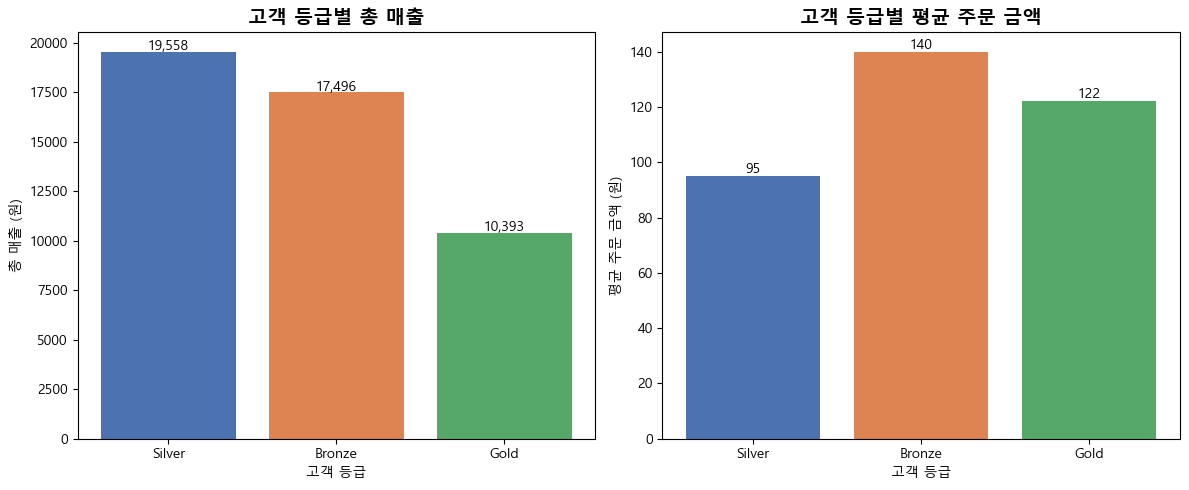

저장: q1_tier_revenue.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(result_q1['고객_등급'], result_q1['총_매출'], color=colors)
axes[0].set_title('고객 등급별 총 매출', fontsize=14, fontweight='bold')
axes[0].set_xlabel('고객 등급'); axes[0].set_ylabel('총 매출 (원)')
for i, v in enumerate(result_q1['총_매출']):
    axes[0].text(i, v + 100, f'{v:,.0f}', ha='center', fontsize=10)

axes[1].bar(result_q1['고객_등급'], result_q1['평균_주문금액'], color=colors)
axes[1].set_title('고객 등급별 평균 주문 금액', fontsize=14, fontweight='bold')
axes[1].set_xlabel('고객 등급'); axes[1].set_ylabel('평균 주문 금액 (원)')
for i, v in enumerate(result_q1['평균_주문금액']):
    axes[1].text(i, v + 1, f'{v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'q1_tier_revenue.png'), dpi=150, bbox_inches='tight')
plt.show(); print('저장: q1_tier_revenue.png')

In [7]:
sql_q2 = """
SELECT c.customer_id, c.name AS 고객명, c.tier AS 등급, c.region AS 지역,
       COUNT(o.order_id) AS 주문_건수, ROUND(SUM(o.amount),2) AS 총_지출액
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_date >= DATE((SELECT MAX(order_date) FROM orders), '-6 months')
  AND o.status != 'Cancelled'
GROUP BY c.customer_id, c.name, c.tier, c.region
ORDER BY 총_지출액 DESC LIMIT 10"""
result_q2 = run_query('최근 6개월 최대 지출 고객 TOP 10', sql_q2)
result_q2

------------------------------------------------------------
[질문] 최근 6개월 최대 지출 고객 TOP 10

[SQL]
SELECT c.customer_id, c.name AS 고객명, c.tier AS 등급, c.region AS 지역,
       COUNT(o.order_id) AS 주문_건수, ROUND(SUM(o.amount),2) AS 총_지출액
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_date >= DATE((SELECT MAX(order_date) FROM orders), '-6 months')
  AND o.status != 'Cancelled'
GROUP BY c.customer_id, c.name, c.tier, c.region
ORDER BY 총_지출액 DESC LIMIT 10

[결과] 10행


,customer_id,고객명,등급,지역,주문_건수,총_지출액
0,CUST058,Felix Bell,Bronze,South,4,2024.98
1,CUST056,Dylan Cook,Gold,West,4,1774.98
2,CUST068,Paul Peterson,Bronze,West,4,1274.99
3,CUST066,Nathan Ward,Gold,South,4,1104.99
4,CUST048,Victor Parker,Bronze,West,3,1049.99
5,CUST028,Blake Moore,Silver,West,2,974.99
6,CUST088,Jack Flores,Gold,West,2,974.99
7,CUST098,Tanya Hayes,Gold,South,1,899.99
8,CUST046,Tanya Phillips,Gold,South,3,889.99
9,CUST026,Zachary Brown,Bronze,South,2,844.99


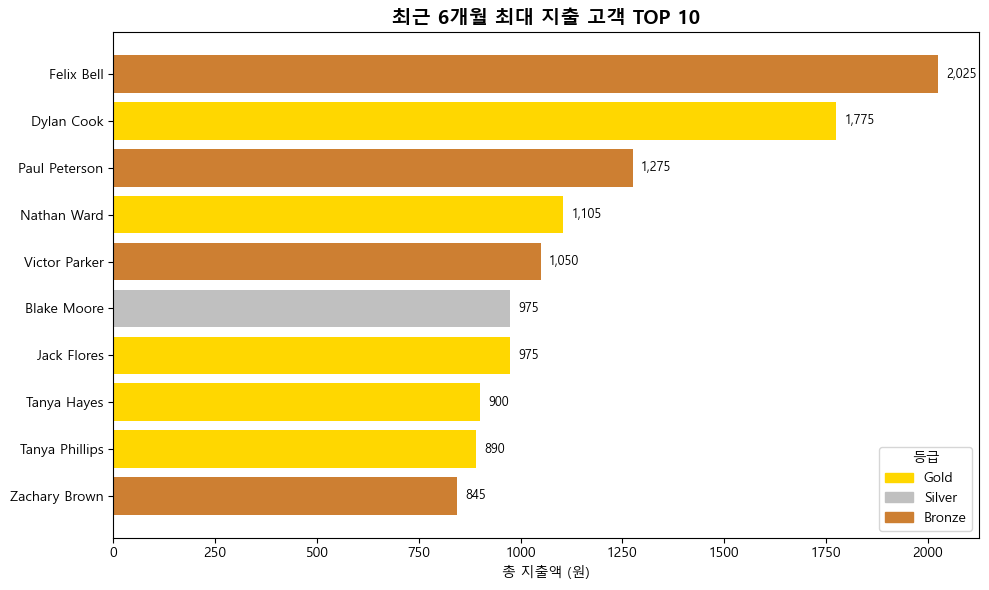

저장: q2_top10_customers.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
tier_colors = {'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'}
bar_colors = [tier_colors.get(t, '#4C72B0') for t in result_q2['등급']]

bars = ax.barh(result_q2['고객명'][::-1], result_q2['총_지출액'][::-1], color=bar_colors[::-1])
ax.set_title('최근 6개월 최대 지출 고객 TOP 10', fontsize=14, fontweight='bold')
ax.set_xlabel('총 지출액 (원)')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 20, bar.get_y() + bar.get_height()/2, f'{w:,.0f}', va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=t) for t, c in tier_colors.items()], title='등급', loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'q2_top10_customers.png'), dpi=150, bbox_inches='tight')
plt.show(); print('저장: q2_top10_customers.png')

In [9]:
sql_q3 = """
WITH monthly AS (
    SELECT p.category, STRFTIME('%Y-%m', o.order_date) AS 년월,
           ROUND(SUM(o.amount),2) AS 월_매출
    FROM orders o JOIN products p ON o.product_id = p.product_id
    WHERE o.status = 'Completed' GROUP BY p.category, 년월
),
with_prev AS (
    SELECT m.category, m.년월, m.월_매출, prev.월_매출 AS 전월_매출
    FROM monthly m
    LEFT JOIN monthly prev ON m.category = prev.category
      AND prev.년월 = STRFTIME('%Y-%m', DATE(m.년월 || '-01', '-1 month'))
)
SELECT category AS 카테고리, 년월, 월_매출, 전월_매출,
       CASE WHEN 전월_매출 IS NULL OR 전월_매출=0 THEN NULL
            ELSE ROUND((월_매출-전월_매출)*100.0/전월_매출,1) END AS 전월대비_성장률_pct
FROM with_prev ORDER BY 카테고리, 년월"""
result_q3 = run_query('제품 카테고리별 전월 대비 매출 성장률', sql_q3)
result_q3

------------------------------------------------------------
[질문] 제품 카테고리별 전월 대비 매출 성장률

[SQL]
WITH monthly AS (
    SELECT p.category, STRFTIME('%Y-%m', o.order_date) AS 년월,
           ROUND(SUM(o.amount),2) AS 월_매출
    FROM orders o JOIN products p ON o.product_id = p.product_id
    WHERE o.status = 'Completed' GROUP BY p.category, 년월
),
with_prev AS (
    SELECT m.category, m.년월, m.월_매출, prev.월_매출 AS 전월_매출
    FROM monthly m
    LEFT JOIN monthly prev ON m.category = prev.category
      AND prev.년월 = STRFTIME('%Y-%m', DATE(m.년월 || '-01', '-1 month'))
)
SELECT category AS 카테고리, 년월, 월_매출, 전월_매출,
       CASE WHEN 전월_매출 IS NULL OR 전월_매출=0 THEN NULL
            ELSE ROUND((월_매출-전월_매출)*100.0/전월_매출,1) END AS 전월대비_성장률_pct
FROM with_prev ORDER BY 카테고리, 년월

[결과] 48행


,카테고리,년월,월_매출,전월_매출,전월대비_성장률_pct
0,Clothing,2024-01,449.97,NaN,NaN
1,Clothing,2024-02,759.94,449.97,68.9
2,Clothing,2024-03,550.00,759.94,-27.6
3,Clothing,2024-04,639.94,550.00,16.4
4,Clothing,2024-05,574.94,639.94,-10.2
5,Clothing,2024-06,609.97,574.94,6.1
6,Clothing,2024-07,529.97,609.97,-13.1
7,Clothing,2024-08,884.91,529.97,67.0
8,Clothing,2024-09,410.00,884.91,-53.7
9,Clothing,2024-10,759.94,410.00,85.4


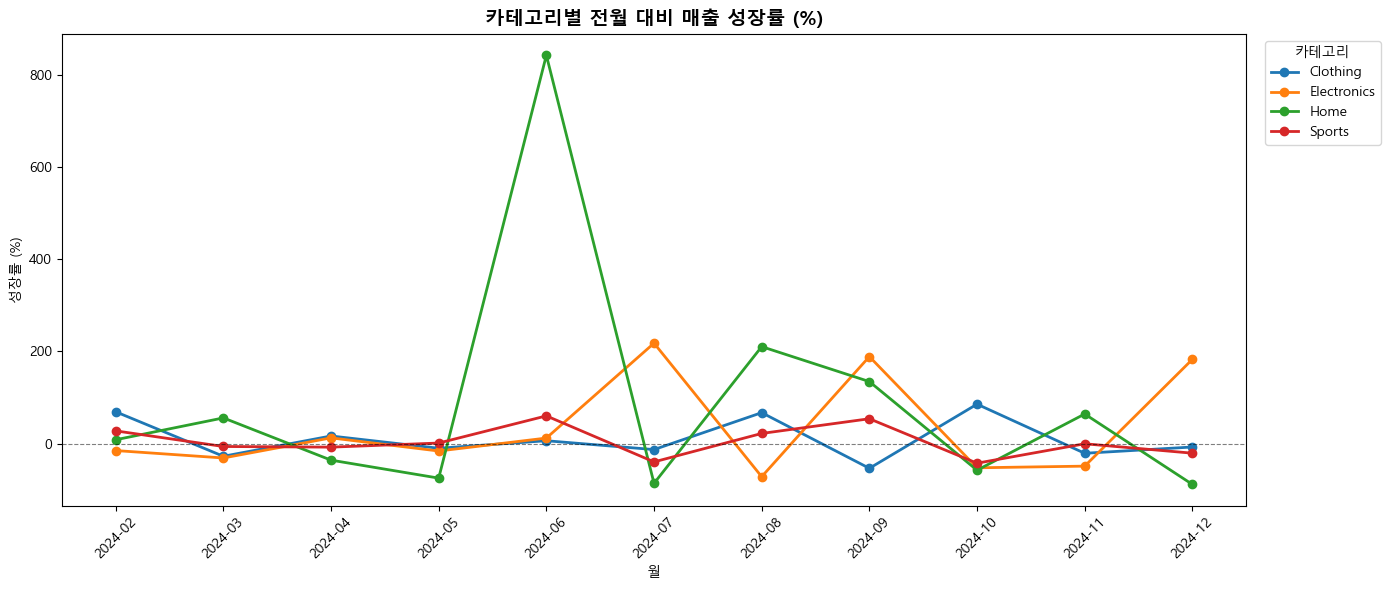

저장: q3_category_growth.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
for cat in result_q3['카테고리'].unique():
    df_cat = result_q3[result_q3['카테고리'] == cat].dropna(subset=['전월대비_성장률_pct'])
    ax.plot(df_cat['년월'], df_cat['전월대비_성장률_pct'], marker='o', linewidth=2, label=cat)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('카테고리별 전월 대비 매출 성장률 (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('월'); ax.set_ylabel('성장률 (%)')
ax.legend(title='카테고리', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'q3_category_growth.png'), dpi=150, bbox_inches='tight')
plt.show(); print('저장: q3_category_growth.png')

In [11]:
sql_q4 = """
SELECT c.customer_id, c.name AS 고객명, c.tier AS 등급, c.region AS 지역,
       COUNT(o.order_id) AS 총_주문수,
       SUM(CASE WHEN o.status='Cancelled' THEN 1 ELSE 0 END) AS 취소_건수
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.name, c.tier, c.region
HAVING 총_주문수 >= 3 AND 취소_건수 = 0
ORDER BY 총_주문수 DESC"""
result_q4 = run_query('3건 이상 주문 & 취소(환불) 이력 없는 고객', sql_q4)
result_q4

------------------------------------------------------------
[질문] 3건 이상 주문 & 취소(환불) 이력 없는 고객

[SQL]
SELECT c.customer_id, c.name AS 고객명, c.tier AS 등급, c.region AS 지역,
       COUNT(o.order_id) AS 총_주문수,
       SUM(CASE WHEN o.status='Cancelled' THEN 1 ELSE 0 END) AS 취소_건수
FROM orders o JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.name, c.tier, c.region
HAVING 총_주문수 >= 3 AND 취소_건수 = 0
ORDER BY 총_주문수 DESC

[결과] 70행


,customer_id,고객명,등급,지역,총_주문수,취소_건수
0,CUST001,Alice Johnson,Silver,North,7,0
1,CUST002,Bob Smith,Bronze,South,7,0
2,CUST003,Carol Davis,Gold,East,7,0
3,CUST006,Frank Miller,Silver,South,7,0
4,CUST007,Grace Lee,Gold,East,7,0
...,...,...,...,...,...,...
65,CUST096,Rachel Russell,Silver,West,3,0
66,CUST097,Samuel Griffin,Bronze,North,3,0
67,CUST098,Tanya Hayes,Gold,South,3,0
68,CUST099,Uma Myers,Silver,East,3,0


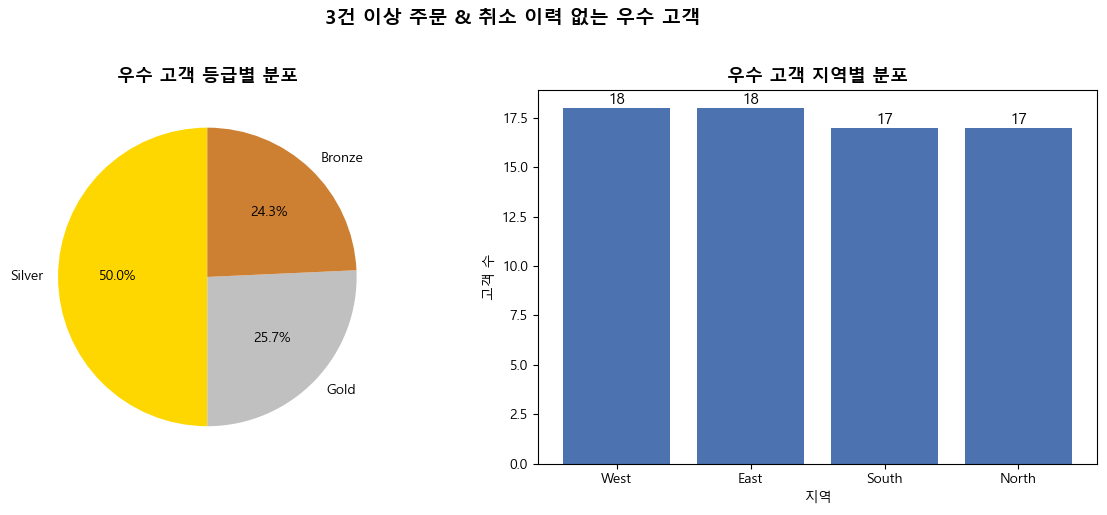

저장: q4_loyal_customers.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tier_cnt = result_q4['등급'].value_counts()
axes[0].pie(tier_cnt, labels=tier_cnt.index, autopct='%1.1f%%',
            colors=['#FFD700', '#C0C0C0', '#CD7F32'], startangle=90)
axes[0].set_title('우수 고객 등급별 분포', fontsize=13, fontweight='bold')

region_cnt = result_q4['지역'].value_counts()
axes[1].bar(region_cnt.index, region_cnt.values, color='#4C72B0')
axes[1].set_title('우수 고객 지역별 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('지역'); axes[1].set_ylabel('고객 수')
for i, v in enumerate(region_cnt.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=11)

plt.suptitle('3건 이상 주문 & 취소 이력 없는 우수 고객', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'q4_loyal_customers.png'), dpi=150, bbox_inches='tight')
plt.show(); print('저장: q4_loyal_customers.png')

In [13]:
sql_q5 = """
WITH overall AS (
    SELECT ROUND(AVG(amount),2) AS 전체_평균 FROM orders WHERE status='Completed'
)
SELECT c.region AS 지역, COUNT(o.order_id) AS 주문_건수,
       ROUND(AVG(o.amount),2) AS 지역_평균, ov.전체_평균,
       ROUND(AVG(o.amount)-ov.전체_평균,2) AS 전체평균_대비_차이,
       ROUND((AVG(o.amount)-ov.전체_평균)*100.0/ov.전체_평균,1) AS 차이_pct
FROM orders o JOIN customers c ON o.customer_id=c.customer_id
CROSS JOIN overall ov
WHERE o.status='Completed'
GROUP BY c.region, ov.전체_평균 ORDER BY 지역_평균 DESC"""
result_q5 = run_query('지역별 평균 주문 금액 vs 전체 평균 비교', sql_q5)
result_q5

------------------------------------------------------------
[질문] 지역별 평균 주문 금액 vs 전체 평균 비교

[SQL]
WITH overall AS (
    SELECT ROUND(AVG(amount),2) AS 전체_평균 FROM orders WHERE status='Completed'
)
SELECT c.region AS 지역, COUNT(o.order_id) AS 주문_건수,
       ROUND(AVG(o.amount),2) AS 지역_평균, ov.전체_평균,
       ROUND(AVG(o.amount)-ov.전체_평균,2) AS 전체평균_대비_차이,
       ROUND((AVG(o.amount)-ov.전체_평균)*100.0/ov.전체_평균,1) AS 차이_pct
FROM orders o JOIN customers c ON o.customer_id=c.customer_id
CROSS JOIN overall ov
WHERE o.status='Completed'
GROUP BY c.region, ov.전체_평균 ORDER BY 지역_평균 DESC

[결과] 4행


,지역,주문_건수,지역_평균,전체_평균,전체평균_대비_차이,차이_pct
0,West,104,138.84,114.06,24.78,21.7
1,South,99,132.92,114.06,18.86,16.5
2,East,107,98.03,114.06,-16.03,-14.1
3,North,106,88.30,114.06,-25.76,-22.6


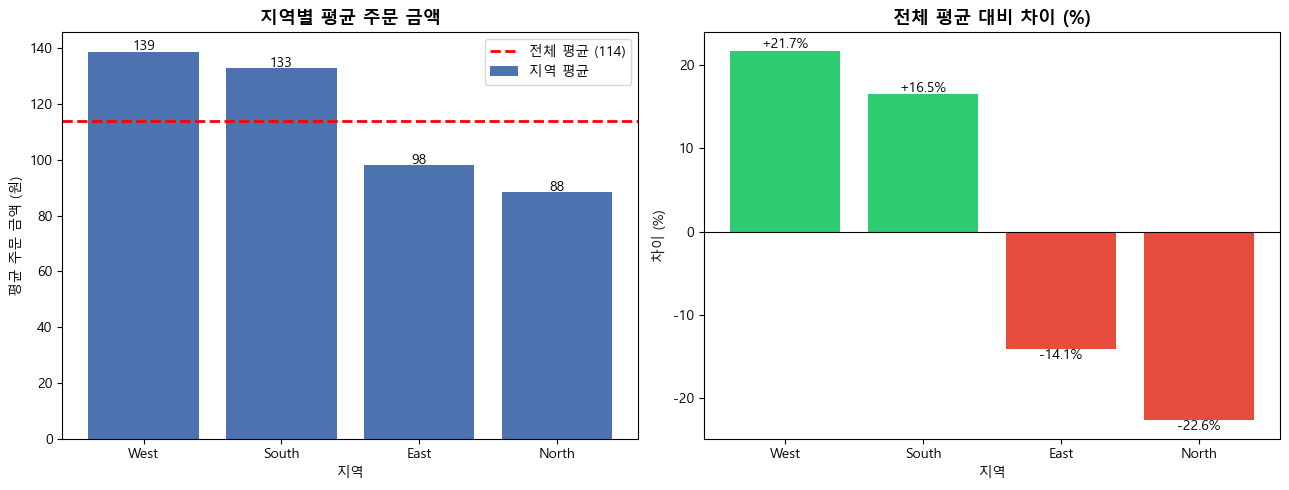

저장: q5_regional_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in result_q5['전체평균_대비_차이']]
overall_avg = result_q5['전체_평균'].iloc[0]

axes[0].bar(result_q5['지역'], result_q5['지역_평균'], color='#4C72B0', label='지역 평균')
axes[0].axhline(overall_avg, color='red', linewidth=2, linestyle='--', label=f'전체 평균 ({overall_avg:,.0f})')
axes[0].set_title('지역별 평균 주문 금액', fontsize=13, fontweight='bold')
axes[0].set_xlabel('지역'); axes[0].set_ylabel('평균 주문 금액 (원)'); axes[0].legend()
for i, v in enumerate(result_q5['지역_평균']):
    axes[0].text(i, v + 0.5, f'{v:,.0f}', ha='center', fontsize=10)

axes[1].bar(result_q5['지역'], result_q5['차이_pct'], color=bar_colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('전체 평균 대비 차이 (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('지역'); axes[1].set_ylabel('차이 (%)')
for i, v in enumerate(result_q5['차이_pct']):
    offset = 0.3 if v >= 0 else -1.2
    axes[1].text(i, v + offset, f'{v:+.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'q5_regional_comparison.png'), dpi=150, bbox_inches='tight')
plt.show(); print('저장: q5_regional_comparison.png')

In [15]:
conn.close()
print('모든 쿼리 실행 완료!')

모든 쿼리 실행 완료!
